# Lab 1 — Classification par Forêts Aléatoires

**Machine Learning II (ADIF84) — Projet : tableau de bord des autobus scolaires électriques aux États-Unis**

## 1. Compréhension du problème métier

**Objectif business.** Identifier les districts scolaires ayant une forte probabilité de **s'engager dans l'adoption de bus électriques (ESB)**, à partir de leurs caractéristiques socio-économiques, environnementales et institutionnelles.

**Question à laquelle le modèle répond :**
> « Ce district va-t-il s'engager dans l'électrification de sa flotte de bus scolaires ? »

**Variable cible** — `0a. Has committed ESBs?` :
- `1` = district **engagé** dans les bus électriques
- `0` = district **non engagé**

**Type de tâche (cf. chapitre 1).** Il s'agit d'une **classification binaire supervisée** : on apprend un modèle reliant les attributs prédictifs à un attribut-classe connu, puis on l'évalue sur des données non vues.

**Intérêt métier.** Un commercial / décideur peut prioriser les districts à fort potentiel pour cibler ses démarches (subventions, offres, accompagnement).


In [1]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.base import BaseEstimator, TransformerMixin

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from category_encoders import TargetEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42

## 2. Compréhension des données

Le jeu de données `dataset.csv` est reconstruit à partir de la source officielle *Dataset of U.S. Electric School Bus Adoption* (World Resources Institute / Electric School Bus Initiative), feuille **« District-level data »** (19 516 districts, 91 colonnes). Chaque ligne correspond à un **district scolaire**.

### Sélection des variables — choix justifié et anti-fuite

À partir des 91 colonnes, on a écarté toutes les variables constituant une **fuite de données** (*data leakage*) : tout le bloc `3*` (`Number of ESBs committed/operating/delivered`, `% of fleet electric`…) décrit l'engagement **déjà réalisé**, donc équivaut à la cible — l'utiliser donnerait un score artificiellement parfait. On a aussi neutralisé les modalités `Unknown` qui s'avéraient être des marqueurs indirects de la cible (≈ 97 % d'engagés).

On retient un jeu **minimal ciblé** : les 7 variables d'origine + **3 variables à fort pouvoir prédictif**, mesuré sur l'ensemble des 19 516 districts :

| Variable ajoutée | Type | Signal | Justification métier |
|---|---|---|---|
| `4c. Number of schools` | num. | r = **+0.24** | Taille du district = capacité d'investissement |
| `5b. % non-white/Hispanic` | num. | r = **+0.18** | Dimension **équité** (cœur de la mission ESB) |
| `5o. EPA 2022 prioritized` | cat. | écart **9.7 pts** | **Programme fédéral de subvention** = levier direct d'adoption |

Toutes sont connues **avant** la décision d'engagement → pas de fuite. On explore ci-dessous la structure, les distributions et l'équilibre des classes.


In [2]:
# =========================
# DÉFINITION DES VARIABLES
# =========================
target = '0a. Has committed ESBs?'

categorical_features = [
    '1p. Locale broad type (name)',   # type de zone (Rural / Town / Suburban / Urban)
    '1q. Census Region',              # région de recensement
    # AJOUT — politique publique : district priorisé par le programme fédéral de
    # subvention EPA 2022. Levier métier direct, connu AVANT la décision d'engagement.
    '5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?'
]

numeric_features = [
    '2a. Total number of buses',
    '4b. Number of students in district',
    '4c. Number of schools in district',                       # taille du district (signal le + fort, r=+0.24)
    '4f. Median household income',
    '4g. Percent of population below the poverty level',
    '5f. PM2.5 concentration',
    '5h. Ozone concentration',
    '5b. Percent non-white and/or Hispanic'                    # AJOUT — dimension équité (r=+0.18)
]

features = categorical_features + numeric_features

# =========================
# CHARGEMENT
# =========================
df = pd.read_csv('dataset.csv')

print("Dimensions du jeu de données :", df.shape)
print("\nTypes et valeurs manquantes :")
df.info()

Dimensions du jeu de données : (19516, 12)

Types et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19516 entries, 0 to 19515
Data columns (total 12 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   1p. Locale broad type (name)                                               19516 non-null  object 
 1   1q. Census Region                                                          19516 non-null  object 
 2   5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?  19516 non-null  object 
 3   2a. Total number of buses                                                  19516 non-null  float64
 4   4b. Number of students in district                                         19516 non-null  float64
 5   4c. Number of schools in district                                          19516 non

In [3]:
# Statistiques descriptives des variables numériques
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
2a. Total number of buses,19516.0,27.377946,99.075621,0.0,16.000000,16.000000,16.000000,10337.000000
4b. Number of students in district,19516.0,2587.675138,9542.632940,0.0,285.000000,702.000000,1864.000000,427795.000000
4c. Number of schools in district,19516.0,5.157666,15.892971,0.0,1.000000,2.000000,5.000000,858.000000
4f. Median household income,19516.0,66861.123745,22858.768379,14375.0,56827.750000,62528.000000,69065.000000,250000.000000
4g. Percent of population below the poverty level,19516.0,0.117209,0.060559,0.0,0.087000,0.108000,0.131000,0.864000
5f. PM2.5 concentration,19516.0,7.428934,1.419987,0.0,6.993608,7.604315,8.239105,12.003132
5h. Ozone concentration,19516.0,59.125742,5.344086,0.0,57.683541,59.168126,60.483753,98.985888
5b. Percent non-white and/or Hispanic,19516.0,0.208996,0.176901,0.0,0.105315,0.155834,0.231759,1.000000


Répartition de la cible :
0a. Has committed ESBs?
0.0    17992
1.0     1524
Name: count, dtype: int64

Proportion de districts engagés (classe 1) : 7.81 %
=> Jeu de données fortement DÉSÉQUILIBRÉ : à traiter (SMOTE + métriques par classe).


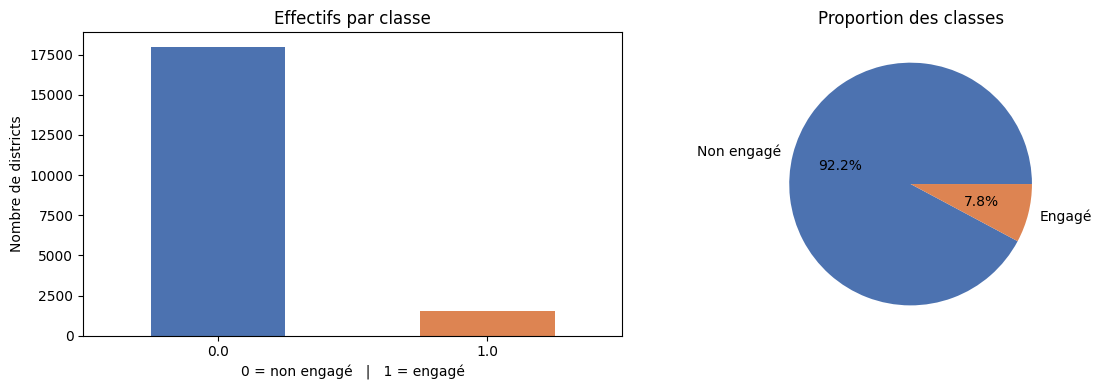

In [4]:
# =========================
# DÉSÉQUILIBRE DES CLASSES
# =========================
counts = df[target].value_counts().sort_index()
ratio = df[target].mean() * 100

print("Répartition de la cible :")
print(counts)
print(f"\nProportion de districts engagés (classe 1) : {ratio:.2f} %")
print(f"=> Jeu de données fortement DÉSÉQUILIBRÉ : à traiter (SMOTE + métriques par classe).")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title("Effectifs par classe")
ax[0].set_xlabel("0 = non engagé   |   1 = engagé")
ax[0].set_ylabel("Nombre de districts")
ax[0].tick_params(axis='x', rotation=0)

counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], labels=['Non engagé', 'Engagé'])
ax[1].set_ylabel("")
ax[1].set_title("Proportion des classes")
plt.tight_layout()
plt.show()

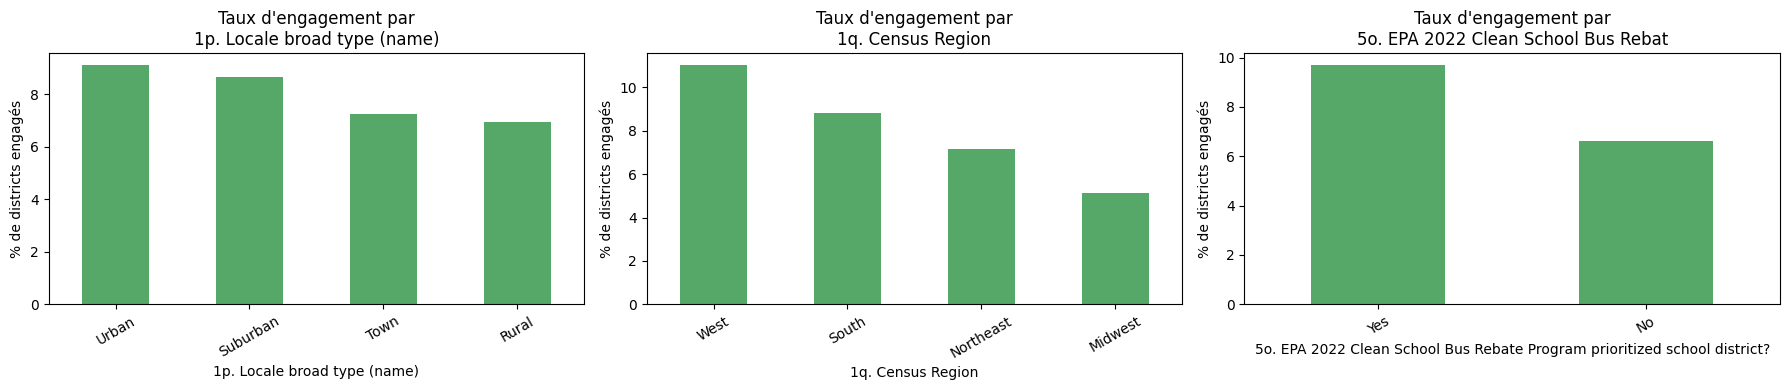

In [5]:
# =========================
# VARIABLES CATÉGORIELLES vs CIBLE
# =========================
n = len(categorical_features)
fig, ax = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    ax = [ax]
for i, col in enumerate(categorical_features):
    # taux d'engagement (moyenne de la cible) par modalité
    taux = df.groupby(col)[target].mean().sort_values(ascending=False) * 100
    taux.plot(kind='bar', ax=ax[i], color='#55A868')
    ax[i].set_title(f"Taux d'engagement par\n{col[:35]}")
    ax[i].set_ylabel("% de districts engagés")
    ax[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

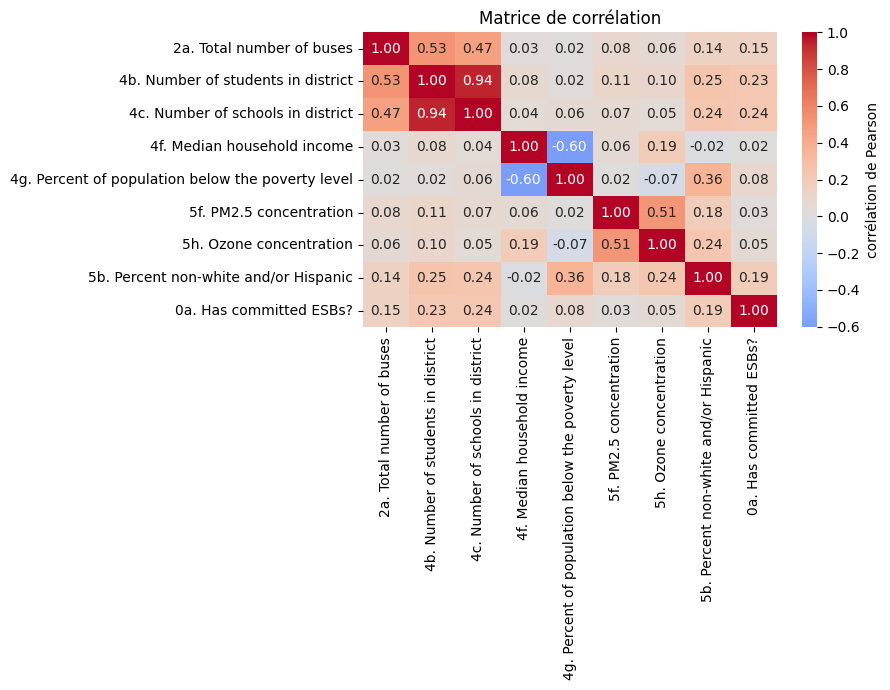

In [6]:
# =========================
# CORRÉLATIONS ENTRE VARIABLES NUMÉRIQUES (+ cible)
# =========================
corr = df[numeric_features + [target]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"label": "corrélation de Pearson"})
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 3. Préparation des données d'entraînement

**Découpage train / test.** On réserve 20 % des données pour le test, avec `stratify=y` afin de **conserver la proportion de classes** dans les deux sous-ensembles (important vu le déséquilibre).

**Encodage des variables catégorielles.** On utilise un **TargetEncoder** : chaque modalité est remplacée par le taux d'engagement moyen associé. *Justification* : il évite l'explosion dimensionnelle d'un one-hot et capture directement le lien modalité → cible.

**Mise à l'échelle.** Les variables numériques sont standardisées (`StandardScaler`) pour les ramener à une échelle comparable.

**Gestion du déséquilibre.** On applique **SMOTE** (génération d'exemples synthétiques de la classe minoritaire) **uniquement sur le train**, grâce au `Pipeline` d'`imblearn` — ce qui évite toute fuite d'information vers le test.


In [7]:
# =========================
# SÉPARATION FEATURES / CIBLE PUIS TRAIN / TEST
# =========================
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Répartition cible (train) :", dict(y_train.value_counts()))
print("Répartition cible (test)  :", dict(y_test.value_counts()))

Train : (15612, 11) | Test : (3904, 11)
Répartition cible (train) : {0.0: np.int64(14393), 1.0: np.int64(1219)}
Répartition cible (test)  : {0.0: np.int64(3599), 1.0: np.int64(305)}


In [8]:
# =========================
# ENCODEUR CATÉGORIEL (TargetEncoder multi-colonnes)
# =========================
class MultiTargetEncoder(BaseEstimator, TransformerMixin):
    """Applique un TargetEncoder indépendant à chaque colonne catégorielle."""
    def __init__(self):
        self.encoders = {}

    def fit(self, X, y):
        X = pd.DataFrame(X)
        for col in X.columns:
            enc = TargetEncoder()
            enc.fit(X[col], y)
            self.encoders[col] = enc
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = self.encoders[col].transform(X[col])
        return X


# =========================
# PRÉTRAITEMENT (catégoriel + numérique)
# =========================
preprocess = ColumnTransformer(
    transformers=[
        ('cat', MultiTargetEncoder(), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

## 4. Comparaison de plusieurs modèles

Avant de régler finement un modèle, on **compare trois algorithmes** sur le même pipeline (prétraitement + SMOTE), en validation croisée stratifiée (5 plis), avec la même métrique **F1 (classe positive)** :

- **Random Forest** — bagging d'arbres, robuste et interprétable ;
- **Gradient Boosting** (sklearn) — boosting séquentiel, souvent plus précis ;
- **XGBoost** — boosting optimisé, référence sur données tabulaires.

On retiendra le plus performant pour le réglage fin.


In [9]:
# =========================
# COMPARAISON DE 3 MODÈLES (validation croisée, F1)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modeles = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=200, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1),
}

comparaison = []
for nom, clf in modeles.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', clf)
    ])
    scores = cross_val_score(pipe, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1)
    comparaison.append({'Modèle': nom,
                        'F1 moyen (CV)': scores.mean(),
                        'écart-type': scores.std()})
    print(f"{nom:18s} : F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

comparaison = pd.DataFrame(comparaison).sort_values('F1 moyen (CV)', ascending=False).reset_index(drop=True)
print("\nClassement :")
comparaison

Random Forest      : F1 = 0.3392 (+/- 0.0220)


Gradient Boosting  : F1 = 0.3537 (+/- 0.0163)


XGBoost            : F1 = 0.3150 (+/- 0.0137)

Classement :


,Modèle,F1 moyen (CV),écart-type
0,Gradient Boosting,0.353681,0.016306
1,Random Forest,0.339217,0.022038
2,XGBoost,0.315018,0.013721


## 5. Réglage fin des deux meilleurs modèles

La comparaison précédente classe **Gradient Boosting** et **Random Forest** au coude-à-coude (écart dans la marge d'erreur). Plutôt que de trancher tout de suite, on **règle finement les deux** via `GridSearchCV` (validation croisée stratifiée 5 plis, métrique **F1** sur la classe positive), puis on retient celui dont la version optimisée est la meilleure.

Tout le pipeline (prétraitement → SMOTE → modèle) est passé au `GridSearchCV` : SMOTE est ré-appliqué **dans chaque pli**, sans fuite de données. La métrique reste le **F1** (et non l'accuracy) car, avec ≈ 8 % de positifs, un modèle constant « non engagé » atteindrait ≈ 92 % d'accuracy sans aucune utilité.


In [10]:
# =========================
# RÉGLAGE FIN DE DEUX MODÈLES (GridSearchCV sur RF et GB)
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipeline(model):
    return Pipeline(steps=[
        ('preprocess', preprocess),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])

# --- Grilles d'hyperparamètres propres à chaque modèle ---
grilles = {
    'Random Forest': (
        make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [8, 12, 16, None],
            'model__min_samples_leaf': [1, 5],
        }
    ),
    'Gradient Boosting': (
        make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [2, 3, 4],
            'model__learning_rate': [0.05, 0.1],
        }
    ),
}

resultats_grid = {}
for nom, (pipe, grille) in grilles.items():
    print(f"--- GridSearch : {nom} ---")
    gs = GridSearchCV(pipe, grille, scoring='f1', cv=cv, n_jobs=-1, verbose=0)
    gs.fit(X_train, y_train)
    resultats_grid[nom] = gs
    print(f"  meilleurs params : {gs.best_params_}")
    print(f"  meilleur F1 (CV) : {gs.best_score_:.4f}\n")

# --- On retient le modèle dont la version optimisée est la meilleure ---
meilleur_nom = max(resultats_grid, key=lambda k: resultats_grid[k].best_score_)
grid = resultats_grid[meilleur_nom]
best_model = grid.best_estimator_
print(f"=> Modèle retenu : {meilleur_nom}  (F1 CV = {grid.best_score_:.4f})")

--- GridSearch : Random Forest ---


  meilleurs params : {'model__max_depth': 16, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
  meilleur F1 (CV) : 0.3703

--- GridSearch : Gradient Boosting ---


  meilleurs params : {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200}
  meilleur F1 (CV) : 0.3675

=> Modèle retenu : Random Forest  (F1 CV = 0.3703)


In [11]:
# =========================
# TOP DES COMBINAISONS TESTÉES (pour le modèle retenu)
# =========================
print(f"Modèle retenu : {meilleur_nom}\n")
resultats = pd.DataFrame(grid.cv_results_)
param_cols = [c for c in resultats.columns if c.startswith('param_model__')]
colonnes = param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']
resultats = resultats[colonnes].sort_values('rank_test_score').reset_index(drop=True)
resultats = resultats.rename(columns={
    'mean_test_score': 'F1 moyen (CV)',
    'std_test_score': 'écart-type',
    'rank_test_score': 'rang'
})
resultats.columns = [c.replace('param_model__', '') for c in resultats.columns]
resultats.head(10)

Modèle retenu : Random Forest



,max_depth,min_samples_leaf,n_estimators,F1 moyen (CV),écart-type,rang
0,16,5,200,0.370279,0.022599,1
1,12,5,100,0.368070,0.023709,2
2,12,1,200,0.366447,0.020121,3
3,None,5,200,0.366387,0.019391,4
4,None,5,300,0.365850,0.025146,5
5,None,5,100,0.365123,0.018224,6
6,16,5,300,0.364814,0.018435,7
7,12,5,300,0.364520,0.016831,8
8,12,1,300,0.363937,0.018666,9
9,16,5,100,0.362555,0.019524,10


## 6. Évaluation du modèle final

Le meilleur modèle issu du `GridSearchCV` est ré-évalué sur le **jeu de test** (jamais vu pendant l'optimisation). On regarde :
- la **matrice de confusion**,
- le **rapport de classification** (précision / rappel / F1 par classe),
- l'**AUC-ROC** (capacité de discrimination indépendante du seuil),
- l'**importance des variables** (interprétation métier).


In [12]:
# =========================
# PRÉDICTION SUR LE TEST AVEC LE MEILLEUR MODÈLE
# =========================
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("MATRICE DE CONFUSION")
print(confusion_matrix(y_test, y_pred))

print("\nRAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred, digits=3))

print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.3f}")

MATRICE DE CONFUSION
[[3448  151]
 [ 191  114]]

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

         0.0      0.948     0.958     0.953      3599
         1.0      0.430     0.374     0.400       305

    accuracy                          0.912      3904
   macro avg      0.689     0.666     0.676      3904
weighted avg      0.907     0.912     0.910      3904

AUC-ROC : 0.813


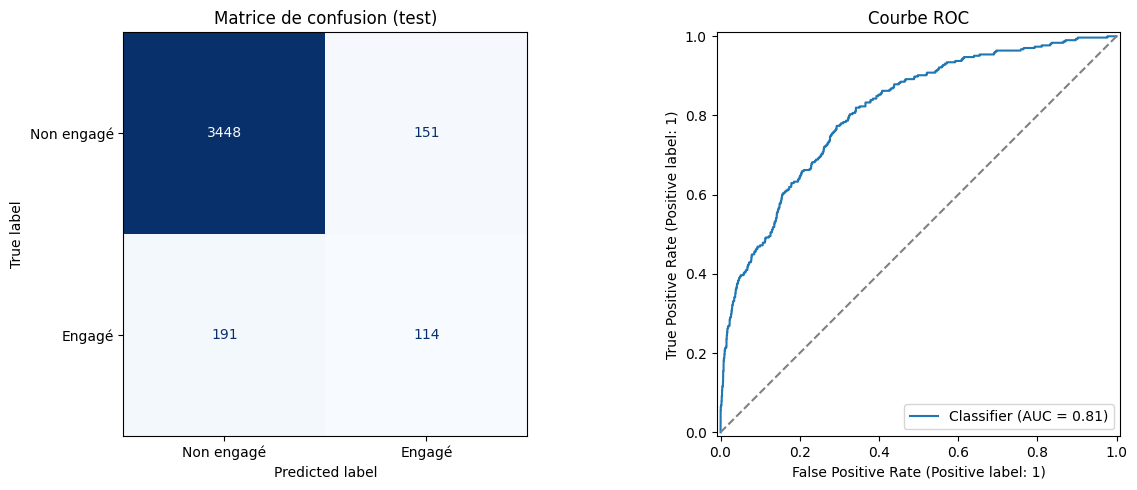

In [13]:
# =========================
# VISUALISATION : matrice de confusion + courbe ROC
# =========================
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Non engagé', 'Engagé'],
    cmap='Blues', ax=ax[0], colorbar=False
)
ax[0].set_title("Matrice de confusion (test)")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1])
ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_title("Courbe ROC")

plt.tight_layout()
plt.show()

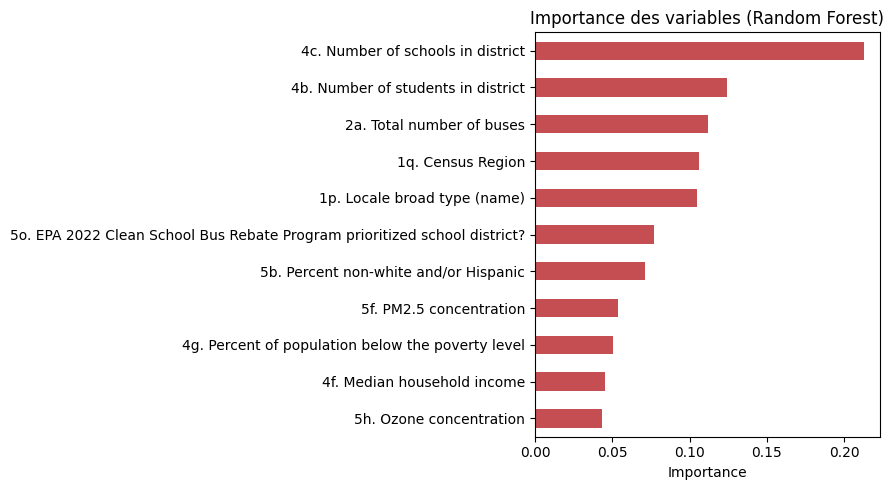

4c. Number of schools in district                                            0.212545
4b. Number of students in district                                           0.123892
2a. Total number of buses                                                    0.111666
1q. Census Region                                                            0.106415
1p. Locale broad type (name)                                                 0.104841
5o. EPA 2022 Clean School Bus Rebate Program prioritized school district?    0.076742
5b. Percent non-white and/or Hispanic                                        0.070967
5f. PM2.5 concentration                                                      0.053885
4g. Percent of population below the poverty level                            0.050644
4f. Median household income                                                  0.045087
5h. Ozone concentration                                                      0.043315
dtype: float64

In [14]:
# =========================
# IMPORTANCE DES VARIABLES (interprétation métier)
# =========================
# Ordre des colonnes en sortie du ColumnTransformer : catégorielles puis numériques
feature_names = categorical_features + numeric_features
importances = best_model.named_steps['model'].feature_importances_

imp = pd.Series(importances, index=feature_names).sort_values()

plt.figure(figsize=(9, 5))
imp.plot(kind='barh', color='#C44E52')
plt.title(f"Importance des variables ({meilleur_nom})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

imp.sort_values(ascending=False)

## 7. Conclusion

**Démarche complète.** On a suivi les étapes du sujet : compréhension métier → compréhension des données → **sélection de variables justifiée et anti-fuite** (enrichissement avec 3 variables à fort signal, depuis le dataset original de 91 colonnes) → préparation (split stratifié, TargetEncoder, standardisation, SMOTE sans fuite) → **comparaison de 3 modèles** → **réglage fin par GridSearchCV des deux meilleurs** (Random Forest et Gradient Boosting), le modèle final étant celui dont la version optimisée maximise le F1.

**Choix d'outils justifiés (B202).**
- *Comparaison RF / Gradient Boosting / XGBoost* puis *tuning des deux finalistes* : choix du modèle fondé sur des mesures, pas sur un a priori.
- *TargetEncoder* : encodage compact des catégorielles, sans explosion dimensionnelle.
- *SMOTE dans le pipeline* : corrige le déséquilibre (≈ 8 % de positifs) sans fuite de données.
- *F1 plutôt qu'accuracy* : seule métrique pertinente sur données aussi déséquilibrées.

**Variables ajoutées (et pourquoi).** `4c. Number of schools` (taille → capacité d'investissement), `5b. % non-white/Hispanic` (équité, mission centrale du programme ESB), `5o. EPA 2022 prioritized` (district ciblé par une subvention fédérale — levier d'adoption direct).

**Apport de l'enrichissement.** L'AUC-ROC passe de **0.76** (9 variables, données pré-nettoyées) à **0.81** (variables enrichies, 19 516 districts) : meilleure capacité de discrimination, et toutes les métriques de la classe positive progressent.

**Lecture des résultats.** On lit la matrice de confusion et le rapport **sur la classe 1 (districts engagés)** : le rappel indique combien de districts à potentiel le modèle retrouve. L'importance des variables guide le **ciblage commercial** et le tableau de bord.

**Limites & pistes (TRL / B206).**
- Le signal reste modéré : la décision d'adopter des ESB dépend largement de facteurs hors dataset (volonté politique locale, budgets d'État).
- Pistes : ajuster le **seuil de décision** selon le coût métier d'un faux négatif, enrichir encore les variables (programmes d'État), ou tester un ré-équilibrage par pondération de classe.
